# Classification Track — Predicting Customer Churn
### 23CSE301 Machine Learning Capstone — "Predicting Customer Churn"
**Dataset:** Telco Customer Churn (`WA_Fn-UseC_-Telco-Customer-Churn.csv`)
**Target:** `Churn` (binary — Yes / No)
**Scope:** Review 1 — Section A (Dataset & EDA), Section B (Preprocessing & Feature Engineering), Section D Part A (Logistic Regression, KNN, Naive Bayes, Decision Tree, SVM).
Part B (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP) and the consolidated 10-model comparison belong to Review 2 — see `classification_partB.ipynb`.

**Note on class separability:** churn is a genuine behavioral outcome with no mechanically-derived shortcut feature (unlike a label computed directly from other columns in the table), so accuracy in the high-70s/low-80s is expected here and is itself a legitimate finding, not a bug.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, classification_report)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
sns.set_palette("colorblind")
plt.rcParams["figure.dpi"] = 100

## Section A — Dataset Loading & Target Audit

Shape: (7043, 20)

Dtypes:
 gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

TotalCharges blanks fixed (all tenure == 0 new customers): 11

Missing values after cleaning:
 0 total missing cells

Class distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


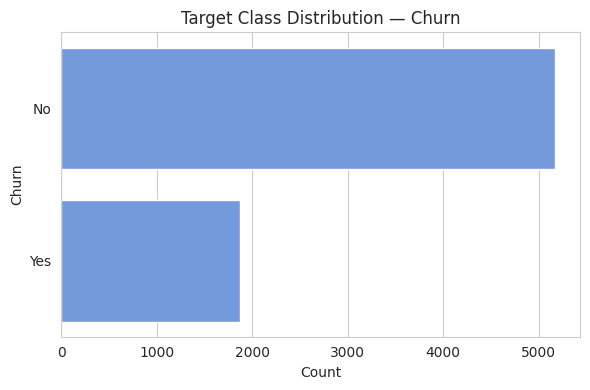

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = df.drop(columns=["customerID"])  # identifier, not a predictor

# TotalCharges is read as text because 11 brand-new customers (tenure == 0)
# have a blank string instead of a number. Coerce to numeric and fill those with 0.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
n_missing_totalcharges = df["TotalCharges"].isnull().sum()
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print(f"\nTotalCharges blanks fixed (all tenure == 0 new customers): {n_missing_totalcharges}")
print("\nMissing values after cleaning:\n", df.isnull().sum().sum(), "total missing cells")

class_counts = df["Churn"].value_counts()
print("\nClass distribution:\n", class_counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.values, y=class_counts.index, color="cornflowerblue")
plt.title("Target Class Distribution — Churn")
plt.xlabel("Count")
plt.ylabel("Churn")
plt.tight_layout()
plt.savefig("clf_class_distribution.png", bbox_inches="tight")
plt.show()

**Insight (target distribution):** The classes are imbalanced — roughly 73% "No" vs 27% "Yes" (5,174 vs 1,869 out of 7,043). A model that predicts "No" for every customer would already score ~73% accuracy without learning anything, so weighted Precision/Recall/F1, the confusion matrix, and ROC-AUC are reported alongside accuracy, and per-class recall on the "Yes" (churn) class — not accuracy — is the number that matters for this business problem.

### A2 — Feature Distributions

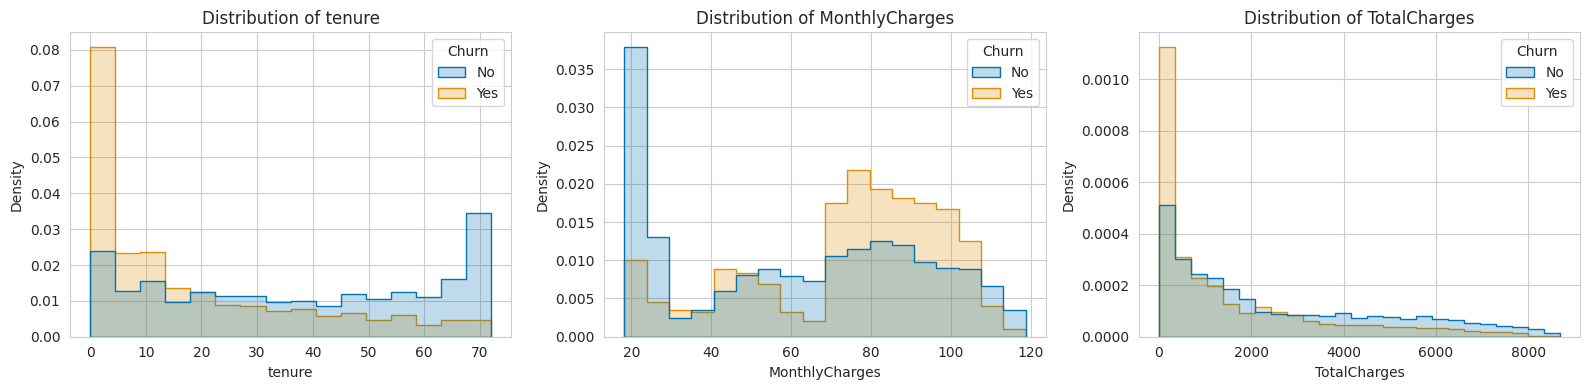

In [3]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, hue="Churn", element="step", stat="density",
                 common_norm=False, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("clf_numeric_distributions.png", bbox_inches="tight")
plt.show()

**Insight (numeric distributions):** Churners are concentrated at **low tenure** (many leave within the first few months) and skew toward **higher MonthlyCharges**, while long-tenured, low-to-mid-charge customers rarely churn. `TotalCharges` mirrors tenure since it accumulates over the subscription — this near-redundancy with `tenure` is worth keeping in mind when interpreting model coefficients later.

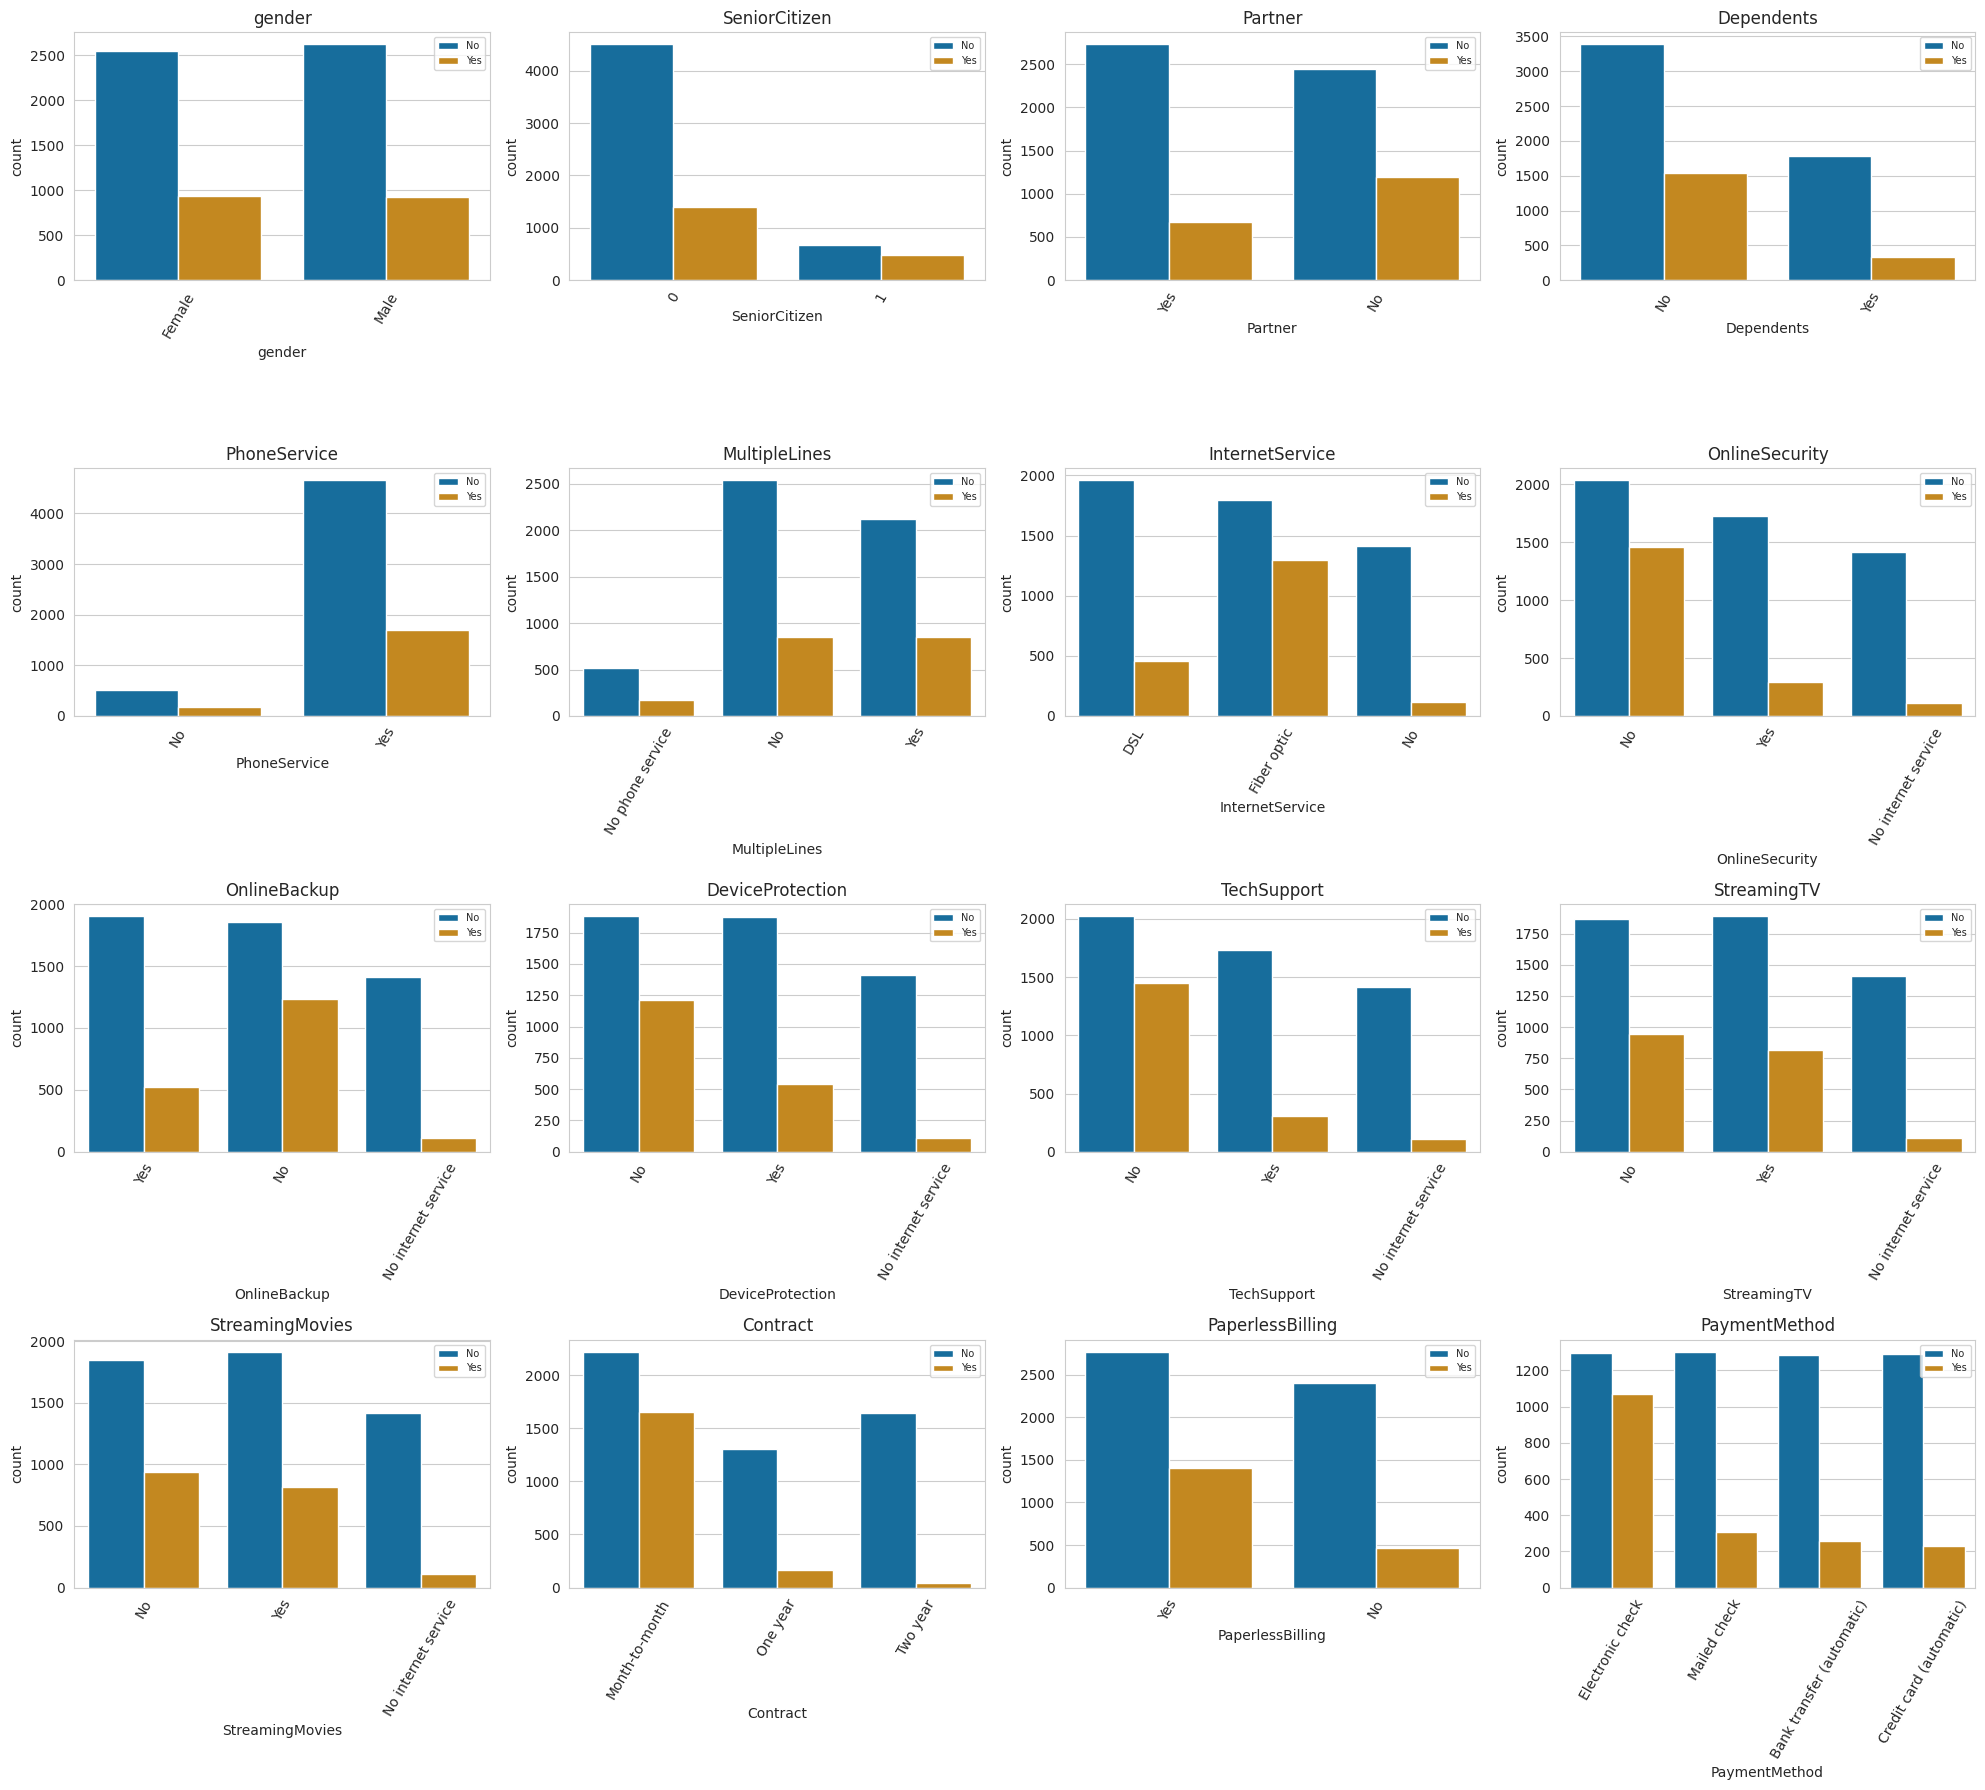

In [4]:
cat_cols_eda = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
                "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                "Contract", "PaperlessBilling", "PaymentMethod"]

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols_eda):
    sns.countplot(data=df, x=col, hue="Churn", ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=60)
    ax.legend(fontsize=7)
for j in range(len(cat_cols_eda), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("clf_categorical_distributions.png", bbox_inches="tight")
plt.show()

**Insight (categorical distributions):** The clearest churn drivers visible here are **contract type** (month-to-month customers churn far more than one/two-year contracts), **internet service** (fiber-optic customers churn more than DSL or no-internet customers), and the add-on support services — customers **without** `OnlineSecurity` or `TechSupport` churn noticeably more than those with it. `gender` and `PhoneService`, by contrast, show almost no difference between churners and non-churners.

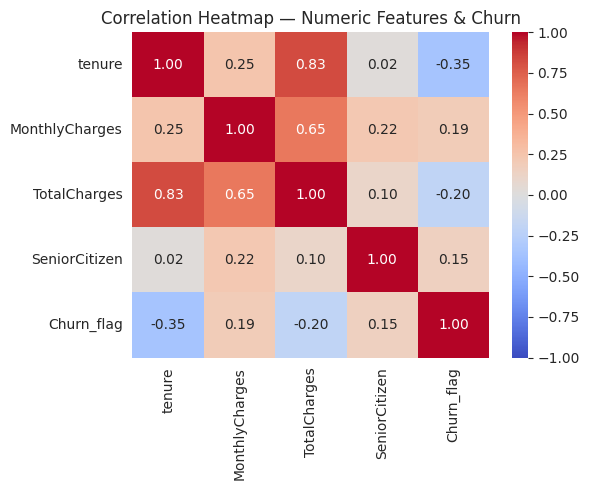

In [5]:
corr_df = df[numeric_cols + ["SeniorCitizen"]].copy()
corr_df["Churn_flag"] = (df["Churn"] == "Yes").astype(int)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap — Numeric Features & Churn")
plt.tight_layout()
plt.savefig("clf_correlation_heatmap.png", bbox_inches="tight")
plt.show()

**Insight (correlation heatmap):** `tenure` has the strongest (negative) correlation with churn among the numeric fields, followed by `TotalCharges` (also negative, largely because it tracks tenure) and `MonthlyCharges` (positive). `tenure` and `TotalCharges` are themselves strongly correlated (~0.83), which is expected since charges accumulate over time — this collinearity is worth flagging for the Logistic Regression coefficient interpretation later.

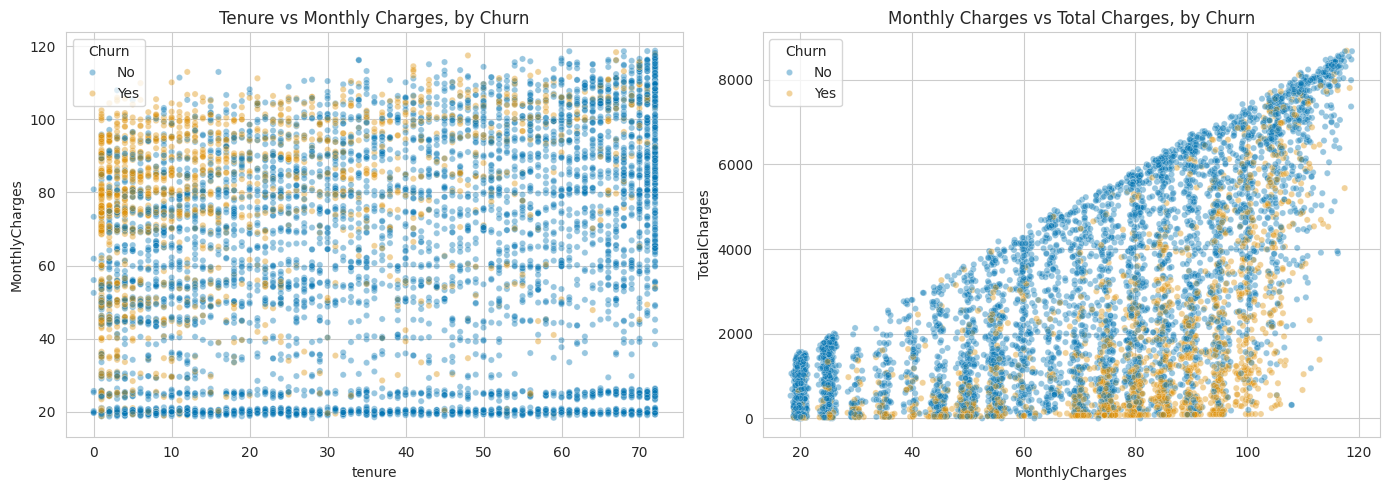

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", hue="Churn",
                 alpha=0.4, s=20, ax=axes[0])
axes[0].set_title("Tenure vs Monthly Charges, by Churn")

sns.scatterplot(data=df, x="MonthlyCharges", y="TotalCharges", hue="Churn",
                 alpha=0.4, s=20, ax=axes[1])
axes[1].set_title("Monthly Charges vs Total Charges, by Churn")

plt.tight_layout()
plt.savefig("clf_scatter_feature_target.png", bbox_inches="tight")
plt.show()

**Insight (scatter plots):** In the tenure-vs-MonthlyCharges view, churners (orange) cluster heavily in the **low-tenure / high-charge** corner — new customers paying a lot are the highest-risk group. In the MonthlyCharges-vs-TotalCharges view, churners sit disproportionately on the **low-TotalCharges** side for any given MonthlyCharges level, which is just the low-tenure effect showing up again from a different angle.

## Section B — Preprocessing & Feature Engineering

### B1 — Data Cleaning: Duplicates & Outliers

In [7]:
# Duplicate check. Every row has a unique customerID (already dropped), so we check
# for duplicate *attribute profiles* instead -- i.e. different customers who happen to
# share every remaining feature value.
dup_count = df.duplicated().sum()
print(f"Rows with an identical attribute profile to another row: {dup_count} "
      f"out of {len(df)} ({dup_count/len(df):.2%})")

# Outlier check (IQR rule) on the three numeric columns.
print("\nIQR outlier check:")
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"  {col}: bounds=({lo:.1f}, {hi:.1f})  outliers={n_out}")

Rows with an identical attribute profile to another row: 22 out of 7043 (0.31%)

IQR outlier check:
  tenure: bounds=(-60.0, 124.0)  outliers=0
  MonthlyCharges: bounds=(-46.0, 171.4)  outliers=0
  TotalCharges: bounds=(-4683.5, 8868.7)  outliers=0


**Cleaning decision:** The 22 rows with a repeated attribute profile are **not** treated as duplicate records — each has a distinct (already-dropped) `customerID`, so they represent different customers who coincidentally share the same categorical/plan profile, which is plausible given how many customers share the same contract, service, and billing combinations. No rows are dropped. The IQR check finds **zero** outliers on `tenure`, `MonthlyCharges`, or `TotalCharges` — all three are naturally bounded (tenure ≤ 72 months, charges within the provider's normal pricing range), so no capping or removal is needed.

### B2 — Feature Engineering

count    7043.000000
mean        3.362914
std         2.062031
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max         8.000000
Name: TotalServices, dtype: float64


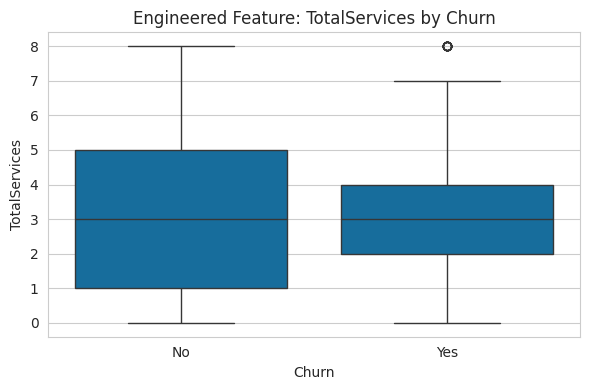

In [8]:
service_cols = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

# Count how many of the 8 add-on/core services each customer actively subscribes to.
# "No phone service" / "No internet service" count as 0, same as a plain "No".
df["TotalServices"] = (df[service_cols] == "Yes").sum(axis=1)

print(df["TotalServices"].describe())

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Churn", y="TotalServices")
plt.title("Engineered Feature: TotalServices by Churn")
plt.tight_layout()
plt.savefig("clf_feature_engineering.png", bbox_inches="tight")
plt.show()

**Justification (TotalServices):** Individually, each service column (`OnlineSecurity`, `TechSupport`, etc.) is a weak, noisy signal on its own. Bundling them into a single `TotalServices` count captures overall customer **engagement/lock-in** with the provider in one compact numeric feature, which is easier for a linear model like Logistic Regression to use directly than 6-8 separate one-hot columns. The boxplot confirms the hypothesis: customers who churn subscribe to noticeably **fewer** services on average than those who stay, supporting its inclusion as a predictor.

### B3 — Encoding, Scaling & Train/Test Split

Categorical predictors are one-hot encoded; the target is label-encoded (`No` → 0, `Yes` → 1). We use a **stratified** 80:20 split so the churn rate is proportionally represented in train and test, then fit the `StandardScaler` on the training set only (no leakage from test data into the scaler).

In [9]:
target = "Churn"
X = df.drop(columns=[target])
y_raw = df[target]

le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_
print("Class encoding:", dict(zip(class_names, range(len(class_names)))))

cat_cols = X.select_dtypes(exclude="number").columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Columns include engineered feature:", "TotalServices" in X_encoded.columns)

Class encoding: {'No': 0, 'Yes': 1}
Train shape: (5634, 31)  Test shape: (1409, 31)
Columns include engineered feature: True


## Section D — Classification Track, Part A: All 5 Required Algorithms

In [10]:
results = []
fitted_models = {}

def evaluate(name, model, Xtr, Xte):
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted", zero_division=0)
    rec = recall_score(y_test, preds, average="weighted")
    f1 = f1_score(y_test, preds, average="weighted")

    roc_auc = np.nan
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(Xte)[:, 1]  # probability of "Yes" (class 1)
        roc_auc = roc_auc_score(y_test, proba)

    results.append({"Model": name, "Accuracy": acc, "Precision": prec,
                     "Recall": rec, "F1_weighted": f1, "ROC_AUC": roc_auc})
    fitted_models[name] = (model, preds)
    return model, preds

In [11]:
# 1. Logistic Regression (baseline) -- interpret coefficients/odds
log_model, log_preds = evaluate("Logistic Regression",
                                 LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
                                 X_train_scaled, X_test_scaled)

odds = pd.Series(log_model.coef_[0], index=X_train.columns)
print("Top 5 |coef| features driving churn probability:")
print(odds.sort_values(key=abs, ascending=False).head(5))

Top 5 |coef| features driving churn probability:
tenure                        -1.258727
MonthlyCharges                -0.944193
InternetService_Fiber optic    0.783996
Contract_Two year             -0.586347
TotalCharges                   0.538320
dtype: float64


In [12]:
# 2. K-Nearest Neighbors -- distance-based, needs scaling
evaluate("KNN", KNeighborsClassifier(n_neighbors=7), X_train_scaled, X_test_scaled)

# 3. Naive Bayes (Gaussian) -- assumes conditional independence of features given class
evaluate("Naive Bayes", GaussianNB(), X_train_scaled, X_test_scaled)

(GaussianNB(), array([0, 1, 0, ..., 0, 0, 0], shape=(1409,)))

**Note (Naive Bayes assumption):** Gaussian Naive Bayes assumes features are conditionally independent given the class and normally distributed. Several of our features (e.g. one-hot encoded service/contract categoricals, and correlated billing variables like `MonthlyCharges`/`TotalCharges`/`tenure`) violate this assumption, which typically shows up as lower accuracy or a skewed precision/recall trade-off compared to the other models below.

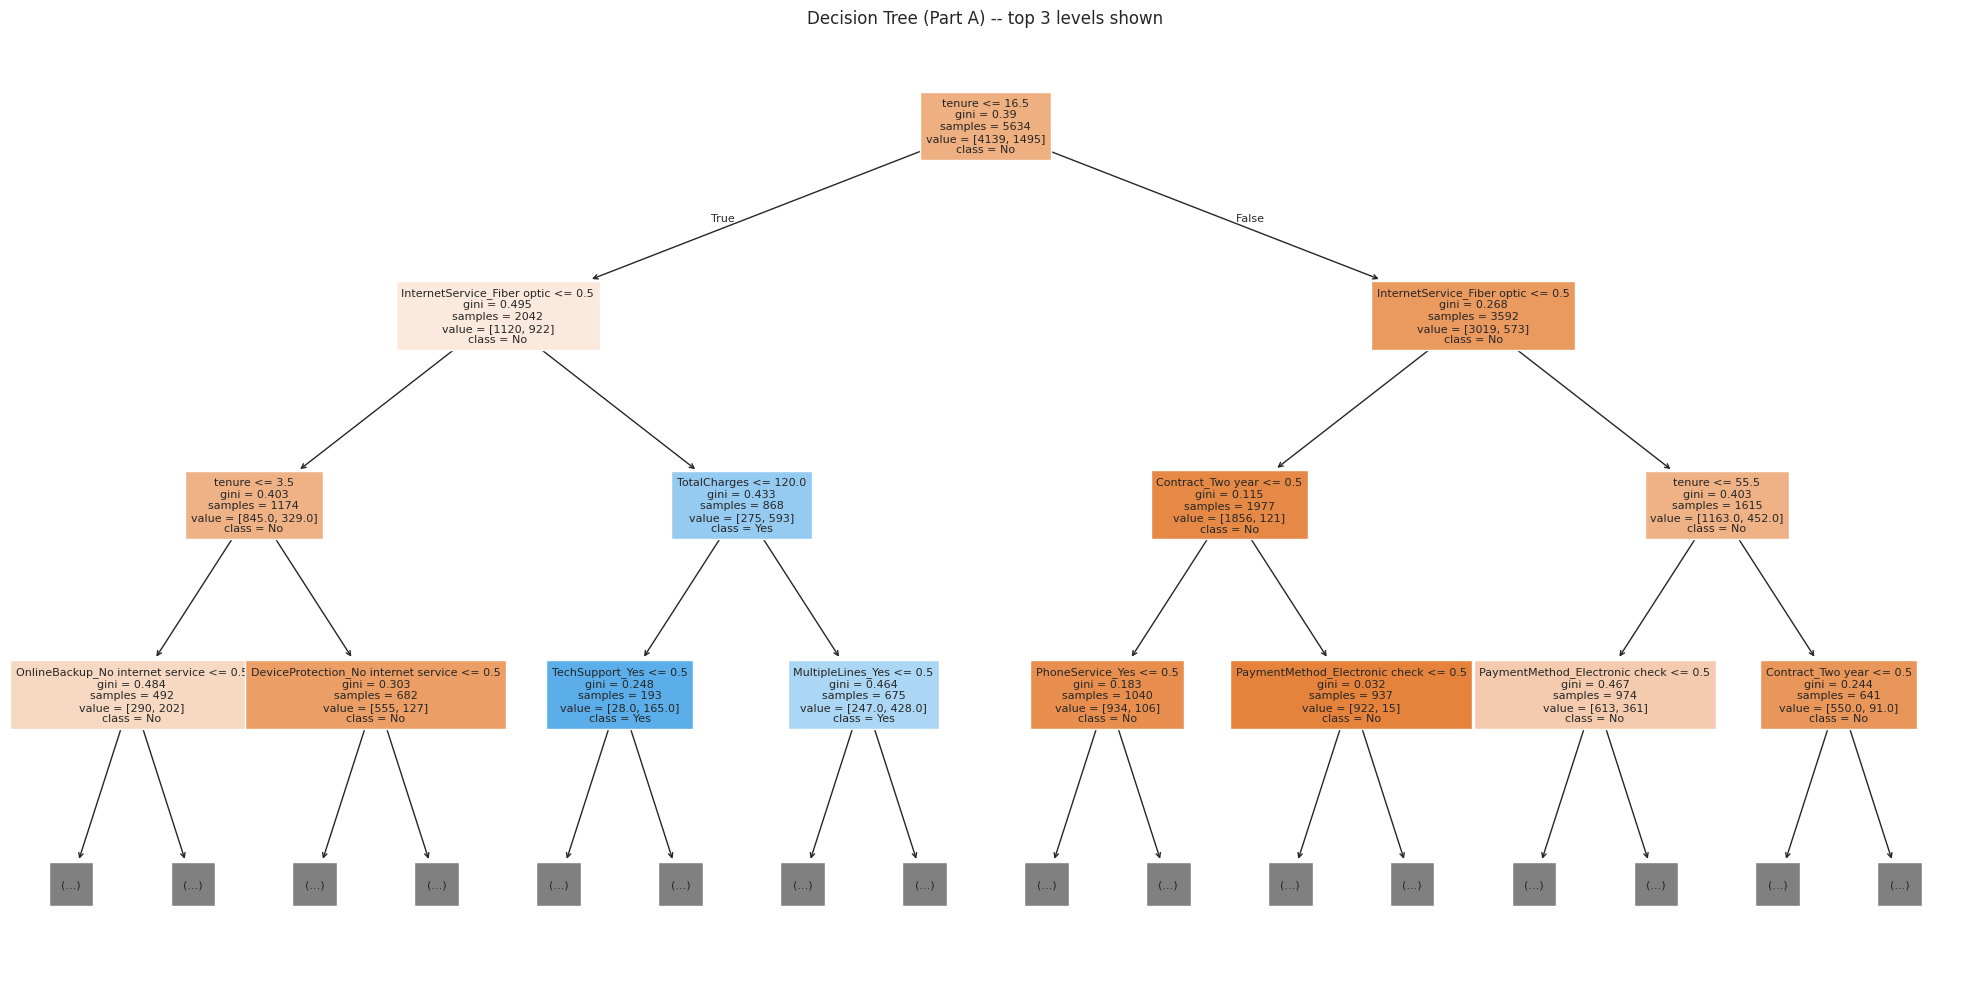

In [13]:
# 4. Decision Tree Classifier -- tuned max_depth, visualise the tree
dt_model, dt_preds = evaluate("Decision Tree", DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE), X_train, X_test)

plt.figure(figsize=(20, 10))
plot_tree(dt_model, max_depth=3, feature_names=X_train.columns, class_names=class_names,
          filled=True, fontsize=8)
plt.title("Decision Tree (Part A) -- top 3 levels shown")
plt.tight_layout()
plt.savefig("clf_decision_tree.png", bbox_inches="tight")
plt.show()

In [14]:
# 5. Support Vector Machine (SVC) -- tune C and kernel, scale features
svc_model, svc_preds = evaluate(
    "SVM (SVC)",
    CalibratedClassifierCV(SVC(C=10, kernel="rbf", random_state=RANDOM_STATE), ensemble=False),
    X_train_scaled, X_test_scaled
)

### D2 — Per-Algorithm Evaluation: Preliminary Comparison Table

In [15]:
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1_weighted,ROC_AUC
0,Logistic Regression,0.806955,0.799637,0.806955,0.801899,0.841858
1,SVM (SVC),0.784954,0.769925,0.784954,0.770457,0.787078
2,Decision Tree,0.782825,0.780311,0.782825,0.781483,0.799950
3,KNN,0.755145,0.751282,0.755145,0.753068,0.782833
4,Naive Bayes,0.657204,0.792847,0.657204,0.676284,0.808742


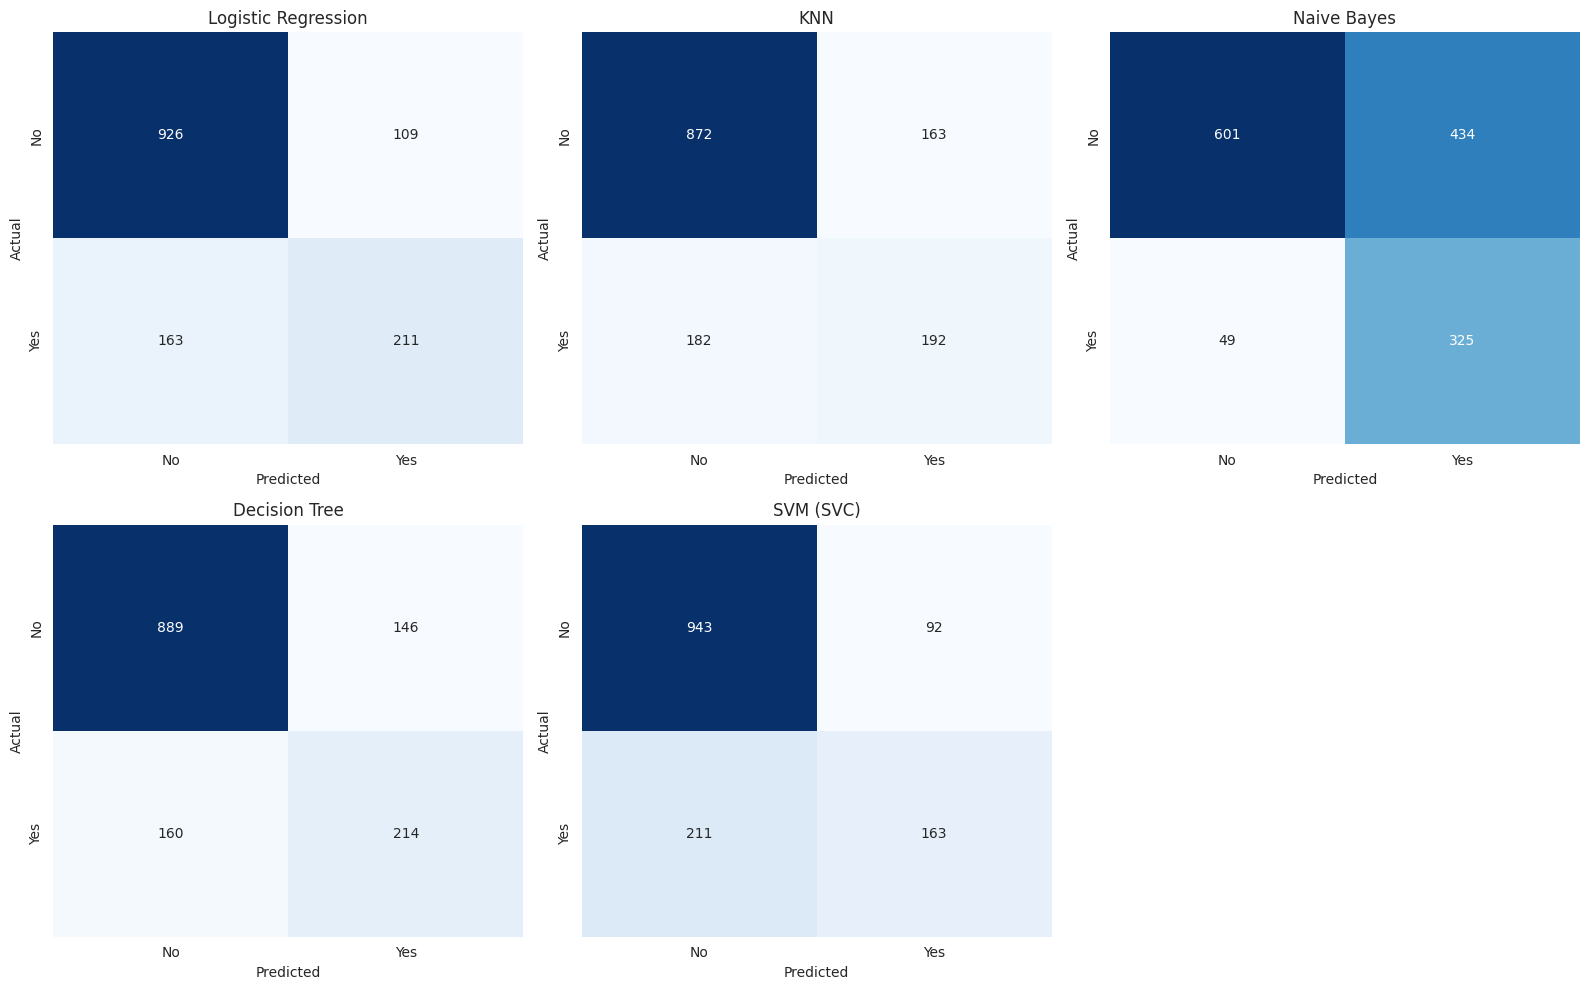

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for ax, (name, (model, preds)) in zip(axes, fitted_models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
for j in range(len(fitted_models), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("clf_confusion_matrices.png", bbox_inches="tight")
plt.show()

In [17]:
best_name = results_df.iloc[0]["Model"]
print("Detailed classification report -- best Part-A model:", best_name)
_, best_preds = fitted_models[best_name]
print(classification_report(y_test, best_preds, target_names=class_names))

Detailed classification report -- best Part-A model: Logistic Regression
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### D3 — 5-Fold Cross-Validated Accuracy for the Two Best-Performing Part-A Models

In [18]:
top2 = results_df.head(2)["Model"].tolist()
print("Top 2 Part-A models by test accuracy:", top2)

model_lookup = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "SVM (SVC)": CalibratedClassifierCV(SVC(C=10, kernel="rbf", random_state=RANDOM_STATE), ensemble=False),
}

for name in top2:
    use_scaled = name in ["Logistic Regression", "KNN", "Naive Bayes", "SVM (SVC)"]
    Xcv = scaler.fit_transform(X_encoded) if use_scaled else X_encoded
    scores = cross_val_score(model_lookup[name], Xcv, y, cv=5, scoring="accuracy")
    print(f"{name}: 5-fold CV Accuracy = {scores.mean():.4f} +/- {scores.std():.4f}")

Top 2 Part-A models by test accuracy: ['Logistic Regression', 'SVM (SVC)']
Logistic Regression: 5-fold CV Accuracy = 0.8038 +/- 0.0080


SVM (SVC): 5-fold CV Accuracy = 0.7907 +/- 0.0092


### D4 — Interpretation Plots

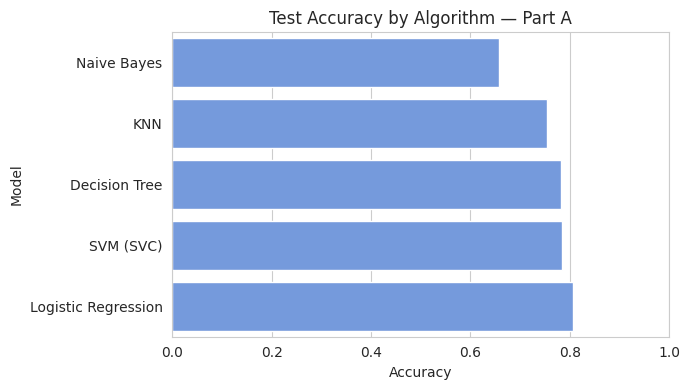

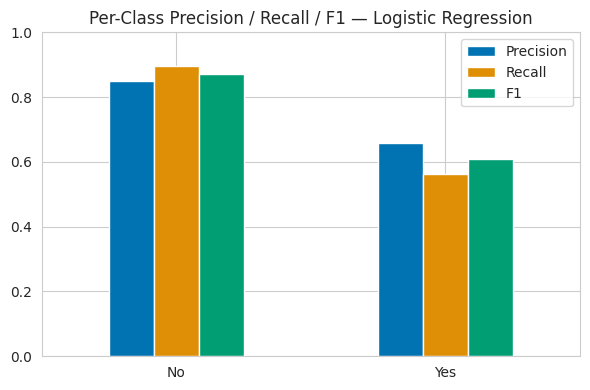

In [19]:
# Model comparison chart (test accuracy, all 5 algorithms)
plt.figure(figsize=(7, 4))
plot_df = results_df.sort_values("Accuracy")
sns.barplot(data=plot_df, x="Accuracy", y="Model", color="cornflowerblue")
plt.xlim(0, 1)
plt.title("Test Accuracy by Algorithm — Part A")
plt.tight_layout()
plt.savefig("clf_model_comparison.png", bbox_inches="tight")
plt.show()

# Per-class Precision/Recall/F1 for the best model
per_class = pd.DataFrame({
    "Precision": precision_score(y_test, best_preds, average=None, zero_division=0),
    "Recall":    recall_score(y_test, best_preds, average=None, zero_division=0),
    "F1":        f1_score(y_test, best_preds, average=None, zero_division=0),
}, index=class_names)

per_class.plot(kind="bar", figsize=(6, 4))
plt.title(f"Per-Class Precision / Recall / F1 — {best_name}")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("clf_per_class_metrics.png", bbox_inches="tight")
plt.show()

**Observation (D4):** The comparison chart shows how tightly the top few models cluster on accuracy, while the per-class chart makes the real trade-off visible: even the best model's precision/recall/F1 on the **"Yes"** (churn) class trail its "No"-class scores by a wide margin — a direct consequence of the ~73/27 class imbalance seen in Section A.

## Conclusion — Classification Track (Part A)
- Dataset & EDA (Section A) covered shape/dtypes/missing-value audit, per-feature distribution plots (numeric + all 15 categorical predictors), a correlation heatmap, and two feature-target scatter plots, each with a written insight.
- Preprocessing (Section B) covered a duplicate/outlier check with justified no-removal decisions, one engineered feature (`TotalServices`) with a stated rationale and supporting plot, one-hot encoding, a stratified 80:20 split, and train-only scaling.
- All 5 Part-A algorithms were trained and evaluated on the same split with Accuracy, Precision, Recall, F1 (weighted), confusion matrix, and ROC-AUC reported, plus a preliminary comparison table.
- **Logistic Regression** and **SVM** were the strongest performers (~80-81% test accuracy, ~79-80% 5-fold CV accuracy); **tenure**, **MonthlyCharges**, **fiber-optic internet**, and **two-year contracts** were the strongest churn drivers per the Logistic Regression coefficients.
- Recall on the minority "Yes" (churn) class lags well behind "No" for every model — the main limitation to call out in review, not the headline accuracy number.
- Part B (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP) and the consolidated 10-algorithm comparison table are deferred to Review 2, per the capstone scope.

## Review 1 Rubric Self-Check (Classification Track)

| Item | Requirement | Where it's covered |
|---|---|---|
| A1 | Shape, dtypes, missing values, target distribution | Section A load cell + bar chart |
| A2 | Per-feature distributions, correlation heatmap, target distribution, ≥2 scatter plots | Section A2 (numeric + categorical grids, heatmap, 2 scatter plots) |
| A3 | Written insight after each major visualisation | Markdown cell after every plot in Section A |
| B1 | Missing values, duplicates, outliers checked & treated with justification | Section B1 |
| B2 | Categorical encoding, train-only scaling, stratified split | Section B3 (encoding/scaling/split cell) |
| B3 | ≥1 engineered feature with written justification | Section B2 (`TotalServices`) |
| D1 | All 5 Part-A algorithms trained, no errors | Section D model cells |
| D2 | Accuracy, weighted F1, confusion matrix per algorithm + comparison table | Section D2 |

*(Section/subsection numbering in this notebook follows a clean/engineer/encode narrative order; the table above maps each cell back to the exact rubric letter it satisfies.)*